Fold 1: Accuracy = 1.0000
Fold 2: Accuracy = 0.9667
Fold 3: Accuracy = 0.9333
Fold 4: Accuracy = 0.9333
Fold 5: Accuracy = 0.9333

Average Accuracy: 0.9533333333333335


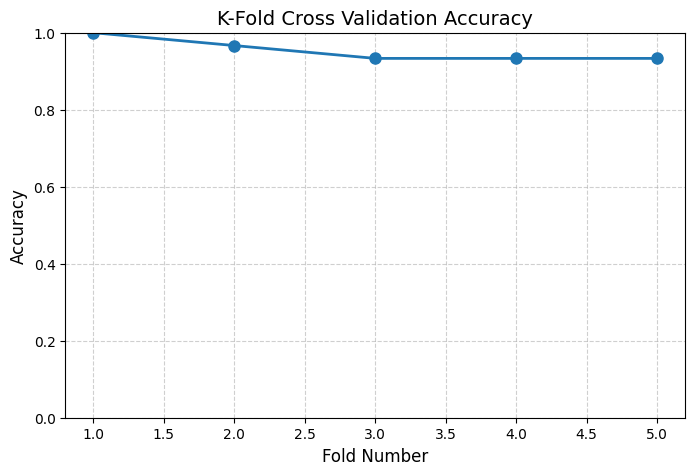

In [2]:
# Step 1: Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris

# Step 2: Load dataset (replace this later with your own CSV if you want)
iris = load_iris()
X = iris.data
y = iris.target

# Step 3: Initialize KFold
k = 5  # Number of folds
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# Step 4: Choose model
model = DecisionTreeClassifier()

# Step 5: Perform K-Fold CV
fold = 1
scores = []

for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Train model
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    scores.append(acc)
    print(f"Fold {fold}: Accuracy = {acc:.4f}")
    fold += 1

# Step 6: Display overall accuracy
print("\nAverage Accuracy:", np.mean(scores))

# Step 7: Plot the results
plt.figure(figsize=(8,5))
plt.plot(range(1, k+1), scores, marker='o', linestyle='-', linewidth=2, markersize=8)
plt.title("K-Fold Cross Validation Accuracy", fontsize=14)
plt.xlabel("Fold Number", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.ylim(0, 1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
